Industry CAGR: 48.96 %


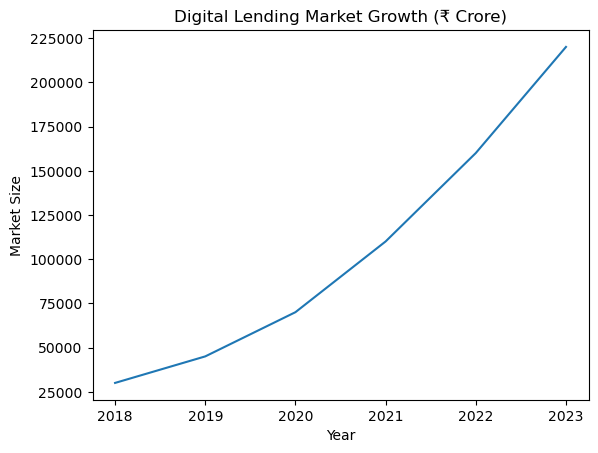

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

data = {
    "Year": [2018,2019,2020,2021,2022,2023],
    "Market_Size": [30000,45000,70000,110000,160000,220000],
    "Default_Rate": [3.5,4.0,5.8,5.2,4.6,4.2]
}

df = pd.DataFrame(data)

# CAGR
begin = df["Market_Size"].iloc[0]
end = df["Market_Size"].iloc[-1]
years = len(df)-1

cagr = (end/begin)**(1/years)-1
print("Industry CAGR:", round(cagr*100,2), "%")

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["Year"], df["Market_Size"])
plt.title("Digital Lending Market Growth (₹ Crore)")
plt.xlabel("Year")
plt.ylabel("Market Size")
plt.show()

Average Default Rate: 4.55 %


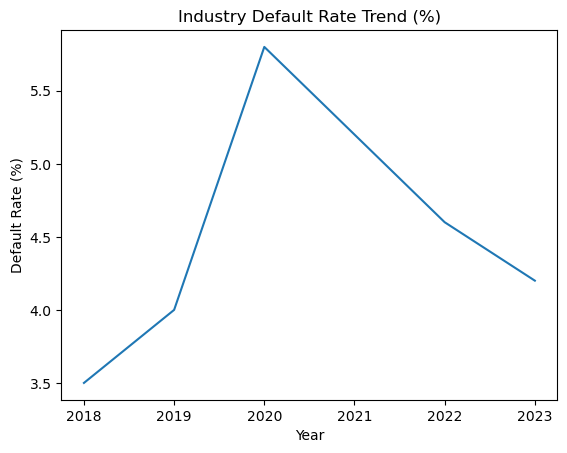

In [8]:
average_pd = df["Default_Rate"].mean()
print("Average Default Rate:", round(average_pd,2), "%")

plt.figure()
plt.plot(df["Year"], df["Default_Rate"])
plt.title("Industry Default Rate Trend (%)")
plt.xlabel("Year")
plt.ylabel("Default Rate (%)")
plt.show()

Correlation: 0.11


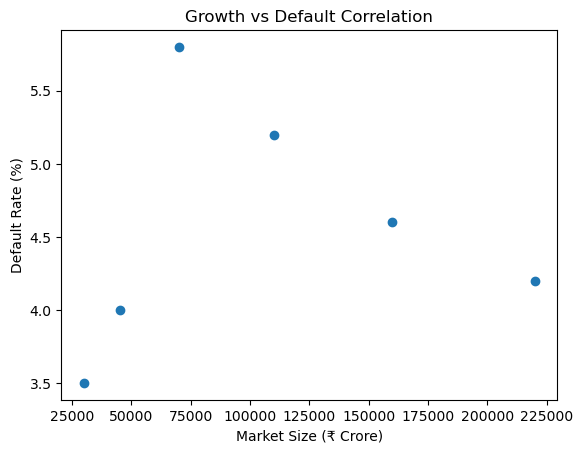

In [9]:
correlation = df["Market_Size"].corr(df["Default_Rate"])
print("Correlation:", round(correlation,3))

plt.figure()
plt.scatter(df["Market_Size"], df["Default_Rate"])
plt.xlabel("Market Size (₹ Crore)")
plt.ylabel("Default Rate (%)")
plt.title("Growth vs Default Correlation")
plt.show()

R-Squared: 0.012


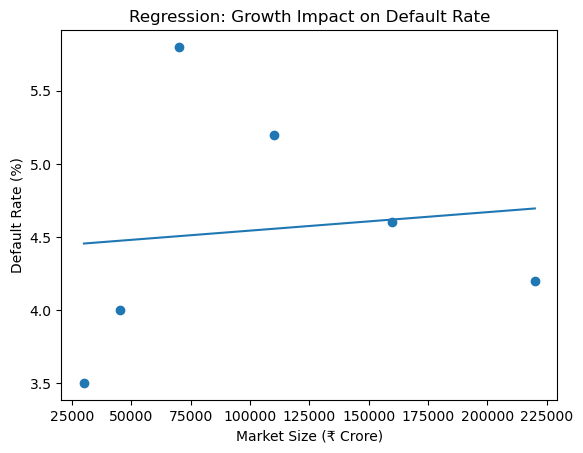

In [11]:
X = df[["Market_Size"]]
y = df["Default_Rate"]

model = LinearRegression()
model.fit(X,y)

print("R-Squared:", round(model.score(X,y),3))

plt.figure()
plt.scatter(df["Market_Size"], df["Default_Rate"])
plt.plot(df["Market_Size"], model.predict(X))
plt.xlabel("Market Size (₹ Crore)")
plt.ylabel("Default Rate (%)")
plt.title("Regression: Growth Impact on Default Rate")
plt.show()

RAROC: 13.18 %


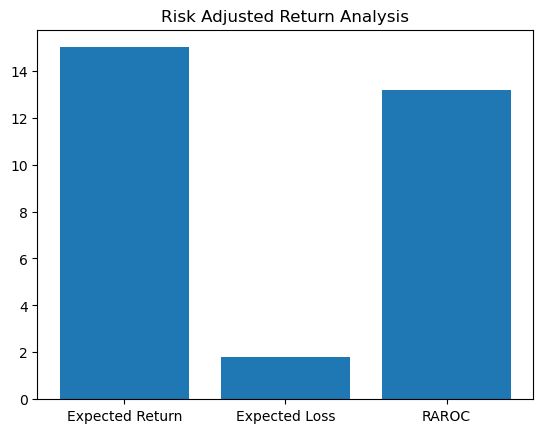

In [12]:
pd_value = df["Default_Rate"].mean()/100
LGD = 0.40
EAD = 100
Expected_Return = 0.15 * EAD

Expected_Loss = pd_value * LGD * EAD
RAROC = (Expected_Return - Expected_Loss)/EAD

print("RAROC:", round(RAROC*100,2), "%")

labels = ["Expected Return","Expected Loss","RAROC"]

values = [Expected_Return, Expected_Loss, RAROC*100]

plt.figure()
plt.bar(labels, values)
plt.title("Risk Adjusted Return Analysis")
plt.show()

ROC-AUC: 0.458


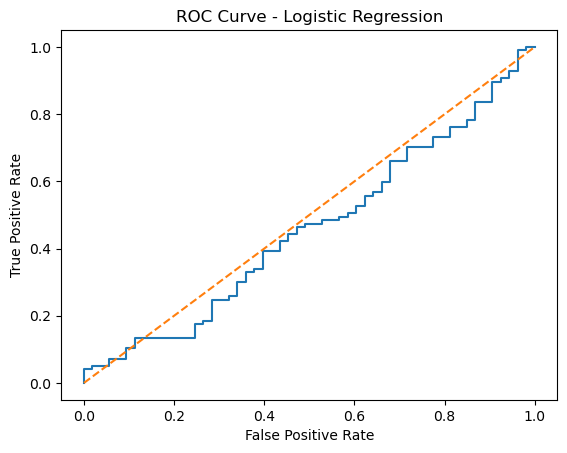

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

np.random.seed(42)
n = 500

transaction_volume = np.random.normal(20000, 5000, n)
refund_rate = np.random.normal(0.05, 0.02, n)
loan_amount = np.random.normal(80000, 20000, n)

default_probability = (
    0.00002*(10000-transaction_volume) +
    8*refund_rate +
    0.000005*loan_amount
)

default_probability = 1/(1+np.exp(-default_probability))
default_flag = np.random.binomial(1, default_probability)

X = np.column_stack((transaction_volume, refund_rate, loan_amount))
y = default_flag

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_prob = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test,y_prob)

print("ROC-AUC:", round(roc_auc,3))

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()